# 09. 「相手のいない」転写が Hfq シグナルを壊す — partnered なら壊さない

> **出典**: Hussein R, Lim HN (2011) *Disruption of small RNA signaling caused by competition for Hfq.* PNAS 108(3):1110-1115.

08（Moon & Gottesman）は「競合 sRNA を過剰発現するとレポーターが抑制される」だった。この論文はさらに踏み込む:

- **unpartnered（相手のいない）sRNA 単独、または mRNA 単独**を転写すると、それらは Hfq に乗ったまま
  singly-bound 複合体($sH$ / $mH$)で **Hfq を抱え込み**、他の sRNA シグナルを強く壊す。
- だが競合 sRNA を**その標的 mRNA と一緒に（partnered）**転写すると、両者は duplex を作って **Hfq を放出**するので、
  Hfq 隔離が最小化され、妨害はずっと小さい。

つまり「**転写を相手と協調させれば Hfq 競合を減らせる**」。同じ競合『量』でも partnered か否かで結果が変わる。

モデルは 08 と同じ2ペア共有 Hfq。競合ペア1の与え方を3通りにする:

| モード | 転写するもの | Hfq への影響 |
|---|---|---|
| `sRNA_only` | s1 だけ | $s1\cdot$Hfq が Hfq を抱える |
| `mRNA_only` | m1 だけ | $m1\cdot$Hfq が Hfq を抱える |
| `partnered` | s1 と m1 を同量 | duplex を作り **Hfq を返す** |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

H = Species('H')
BETA, KA, KD, K5 = 1.0, 1.0, 1.0, 10.0
def R(a,b,k): return ReactionRule(a,b,k)

def pair_rules(i, a_s, a_m):
    s,m,sH,mH,T,D = (Species(f'{x}{i}') for x in ['s','m','sH','mH','T','D'])
    return [R([],[s],a_s), R([],[m],a_m), R([s],[],BETA), R([m],[],BETA),
            R([s,H],[sH],KA), R([sH],[s,H],KD), R([m,H],[mH],KA), R([mH],[m,H],KD),
            R([sH,m],[T],KA), R([T],[sH,m],KD), R([mH,s],[T],KA), R([T],[mH,s],KD),
            R([T],[D,H],K5), R([sH],[H],BETA), R([mH],[H],BETA), R([T],[H],BETA), R([D],[],BETA)]

NAMES = ['H'] + [f'{x}{i}' for i in (1,2) for x in ['s','m','sH','mH','T','D']]
MODES = {'sRNA_only':(1.,0.), 'mRNA_only':(0.,1.), 'partnered':(1.,1.)}

def build(h_tot, mode, load):
    fs, fm = MODES[mode]; mdl = NetworkModel()
    for r in pair_rules(1, fs*load, fm*load) + pair_rules(2, 10., 10.):
        mdl.add_reaction_rule(r)
    return mdl

def state(h_tot, mode, load):
    ret = run_simulation(600., y0={'H':h_tot}, model=build(h_tot,mode,load), solver='ode', ndiv=1, species_list=NAMES)
    return dict(zip(NAMES, ret.as_array()[-1][1:]))

def reporter(h_tot, mode, load):
    v = state(h_tot,mode,load); tot = v['m2']+v['mH2']+v['T2']+v['D2']
    return 100*v['D2']/tot if tot > 0 else 0.0
def seq_by_competitor(h_tot, mode, load):
    v = state(h_tot,mode,load); return 100*(v['sH1']+v['mH1']+v['T1'])/h_tot
print('ready')

ready


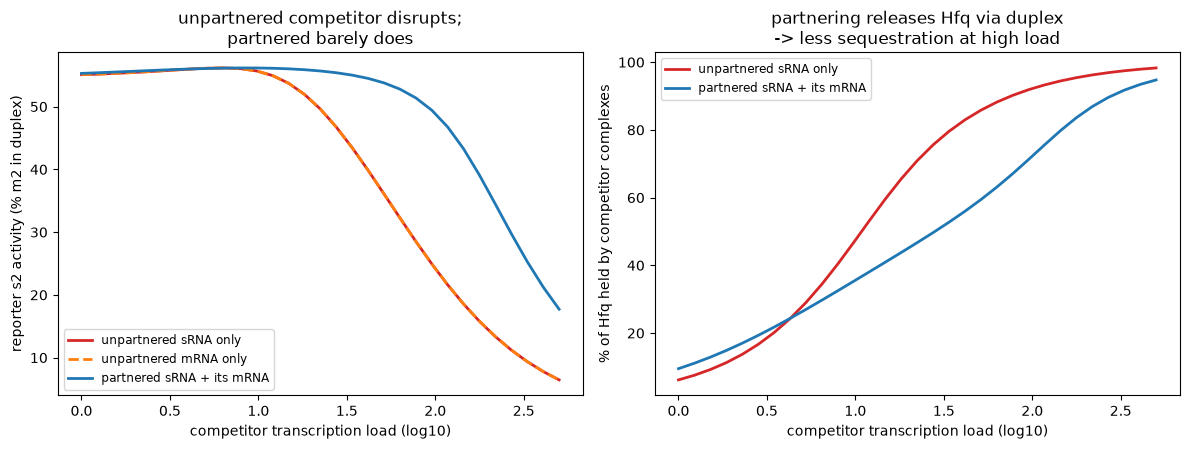

In [2]:
load = np.logspace(0, 2.7, 31)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for mode, c, ls, lab in [('sRNA_only','C3','-','unpartnered sRNA only'),
                         ('mRNA_only','C1','--','unpartnered mRNA only'),
                         ('partnered','C0','-','partnered sRNA + its mRNA')]:
    y = np.array([reporter(12., mode, a) for a in load])
    ax1.plot(np.log10(load), y, ls, color=c, lw=2, label=lab)
ax1.set_xlabel('competitor transcription load (log10)')
ax1.set_ylabel('reporter s2 activity (% m2 in duplex)')
ax1.set_title('unpartnered competitor disrupts;\npartnered barely does'); ax1.legend(fontsize=8.5)

for mode, c, lab in [('sRNA_only','C3','unpartnered sRNA only'), ('partnered','C0','partnered sRNA + its mRNA')]:
    y = np.array([seq_by_competitor(12., mode, a) for a in load])
    ax2.plot(np.log10(load), y, '-', color=c, lw=2, label=lab)
ax2.set_xlabel('competitor transcription load (log10)')
ax2.set_ylabel('% of Hfq held by competitor complexes')
ax2.set_title('partnering releases Hfq via duplex\n-> less sequestration at high load'); ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 同じ競合『量』でも、**unpartnered な sRNA 単独 / mRNA 単独（赤・橙）は強くレポーターを壊す**が、
  **partnered（相手と一緒に転写・青）はほとんど壊さない**。sRNA 単独と mRNA 単独が重なるのも面白い——
  どちらも「片割れ」が Hfq を singly-bound で抱え込む点で等価。
- **右**: 高負荷では、partnered の方が Hfq 占有が低い。partnered は duplex を作って Hfq を返すので、
  抱え込みが飽和しにくい。unpartnered は返す先がなく Hfq をほぼ使い切る。

**含意（合成生物学へ）**: sRNA 回路を設計するとき、sRNA を単独で大量発現すると意図せず Hfq を枯渇させ、
宿主の別の sRNA を巻き込んで壊す。**標的とペアで発現を設計**すれば副作用を抑えられる。

**08 との違い**: 08 は「競合者を増やすと負ける／Hfq 追加で回復」。09 は「同じ量でも *相手がいるかどうか*（partnered か）で
妨害が決まる」——競合の"質"に踏み込んだ。

## 発展課題（自作）

1. partnered でも duplex 形成 `K5` を遅くすると（Hfq をなかなか返さない）、妨害は unpartnered に近づくか？
2. 競合 sRNA の Hfq 結合を強め（`KA`↑）ると、partnered/unpartnered の差はどう変わる？
3. レポーターを「活性化型」（duplex が標的を安定化）に読み替えても同じ結論になるか、概念的に考える。
4. [[bio-a_hfq-phylogenetics]]: 相手 mRNA と共発現される sRNA と、単独で強く誘導される sRNA では、
   ゲノム上の配置・発現制御に進化的な違いがあるかもしれない。partnered/unpartnered をゲノム文脈と結びつけて考える。